# Где дешевле жить? Предсказание цен в Airbnb - учимся генерировать признаки и интерпретировать результаты модели

блок в самом низу # run pipeline - это для запуска моделей, конфиги - там же

функции про фичи и энкодинг:
- column_to_ohe(df_name, column_name, prefix_name)
- label_encode(df_name, column_name, suffix_name='_coded')
- calculate_distance_to_manhattan(df_name, column_name='manh_center_dist', lat_col='latitude', lon_col='longitude')


визуализация в блоках:
- raw data visualization
- pair plot

---

### Что делал
Самый первый прогон со стандарт скейлером и
Linear Regression, RidgeCV, LassoCV,ElasticNetCV показал R^2 ~ 0.0971. Что есть полный провал (в самом низу есть таблица подробнее)

2 дня потратил на эксперименты, комбинации скейлеров, новые комбинированные фичи (без учета таргета), разные способы энкодинга категорийных столбцов.

МАЕ ниже 62$ не смог получить.

Пошел читать комменты про этот датасет. Не нашел удачных примеров с фичами. Согласен с отзывами, что сам датасет хоть и имеет данные, но информативность этих данных низкая. Либо это искусственная генерация с искажениями. Есть стойкое ощущение, что либо не хватает влияющих столбцов, либо они были намерянно убраны из датасета до публикации в кагл.

Ради интереса взял произведение цены на мин_количество_ночей как доп столбец в обучении. Фактически это читинг и прямая подсказка на цену.

Но даже с таким усилением random forest выдал MAE около 26.25$ и смог объяснить ~90% строк.

Отдал весь свой код по блокам в дипсик со скилами через opencode. Попросил добавить логи в csv, вынести настройки в конфиг пайплайна. В итоге добавились всякие улучшайзинги кода, но не модели. Единственное что полезное добавил ии, это log_transform_target(Y, use_log_transform=True). Я про такое не знал.
Результаты в пределах: мае - 56,6$ rmse - 215.45$ . Лучшая модель пока что randomforest (из использованных). Думаю, из того что пробовал на других датасетах, xgboost было бы еще лучше

---

### Выводы
Какой опыт я вынес из этого упражнения - результат по модели так себе, удачных комбинаций фич не нашел, лучшая модель из проверенных - random forest (лучшие настройки есть в логах csv) время потрачено, -5 пунктов к самооценке. Возможно я допустил какие-то фундаментальные ошибки в подходе, но не смог понять какие. А может датасет такой. Похоже, надо искать практический курс по feature engineering. Результаты прогонов есть в model_results.csv.


In [95]:
#YOUR CODE HERE

# import all libs

import pandas as pd
import numpy as np
import time
from datetime import datetime, timezone, timedelta

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split, cross_validate

import warnings
warnings.filterwarnings('ignore')
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns


In [96]:
# load raw .csv

df_raw=pd.read_csv('../datasets/AB_NYC_2019.csv')
print(f'rows:{df_raw.shape[0]}  columns:{df_raw.shape[1]}')
df_raw.head()


rows:48895  columns:16


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [97]:
# drop not required columns
remove_columns=['id', 'name', 'host_id', 'host_name', 'last_review']

df_raw=df_raw.drop(columns=remove_columns)
print(f'rows:{df_raw.shape[0]}  columns:{df_raw.shape[1]}')
df_raw.head()

rows:48895  columns:11


,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


In [98]:
# raw data visualization

# function to get one column stats
def column_stats_table(df_check, column_check):
    counts = df_check[column_check].value_counts()
    percentages = df_check[column_check].value_counts(normalize=True) * 100

    column_stats = pd.DataFrame({
        'value': counts.index,
        'count': counts.values,
        'percentage': percentages.values
    })
    return column_stats


def distribution_plot(df_check):
    plt.rc('axes', titlesize=16)
    df_check.hist(figsize=(18, 11), xlabelsize=10, ylabelsize=10)
    plt.tight_layout(h_pad=3.0, w_pad=2.0)



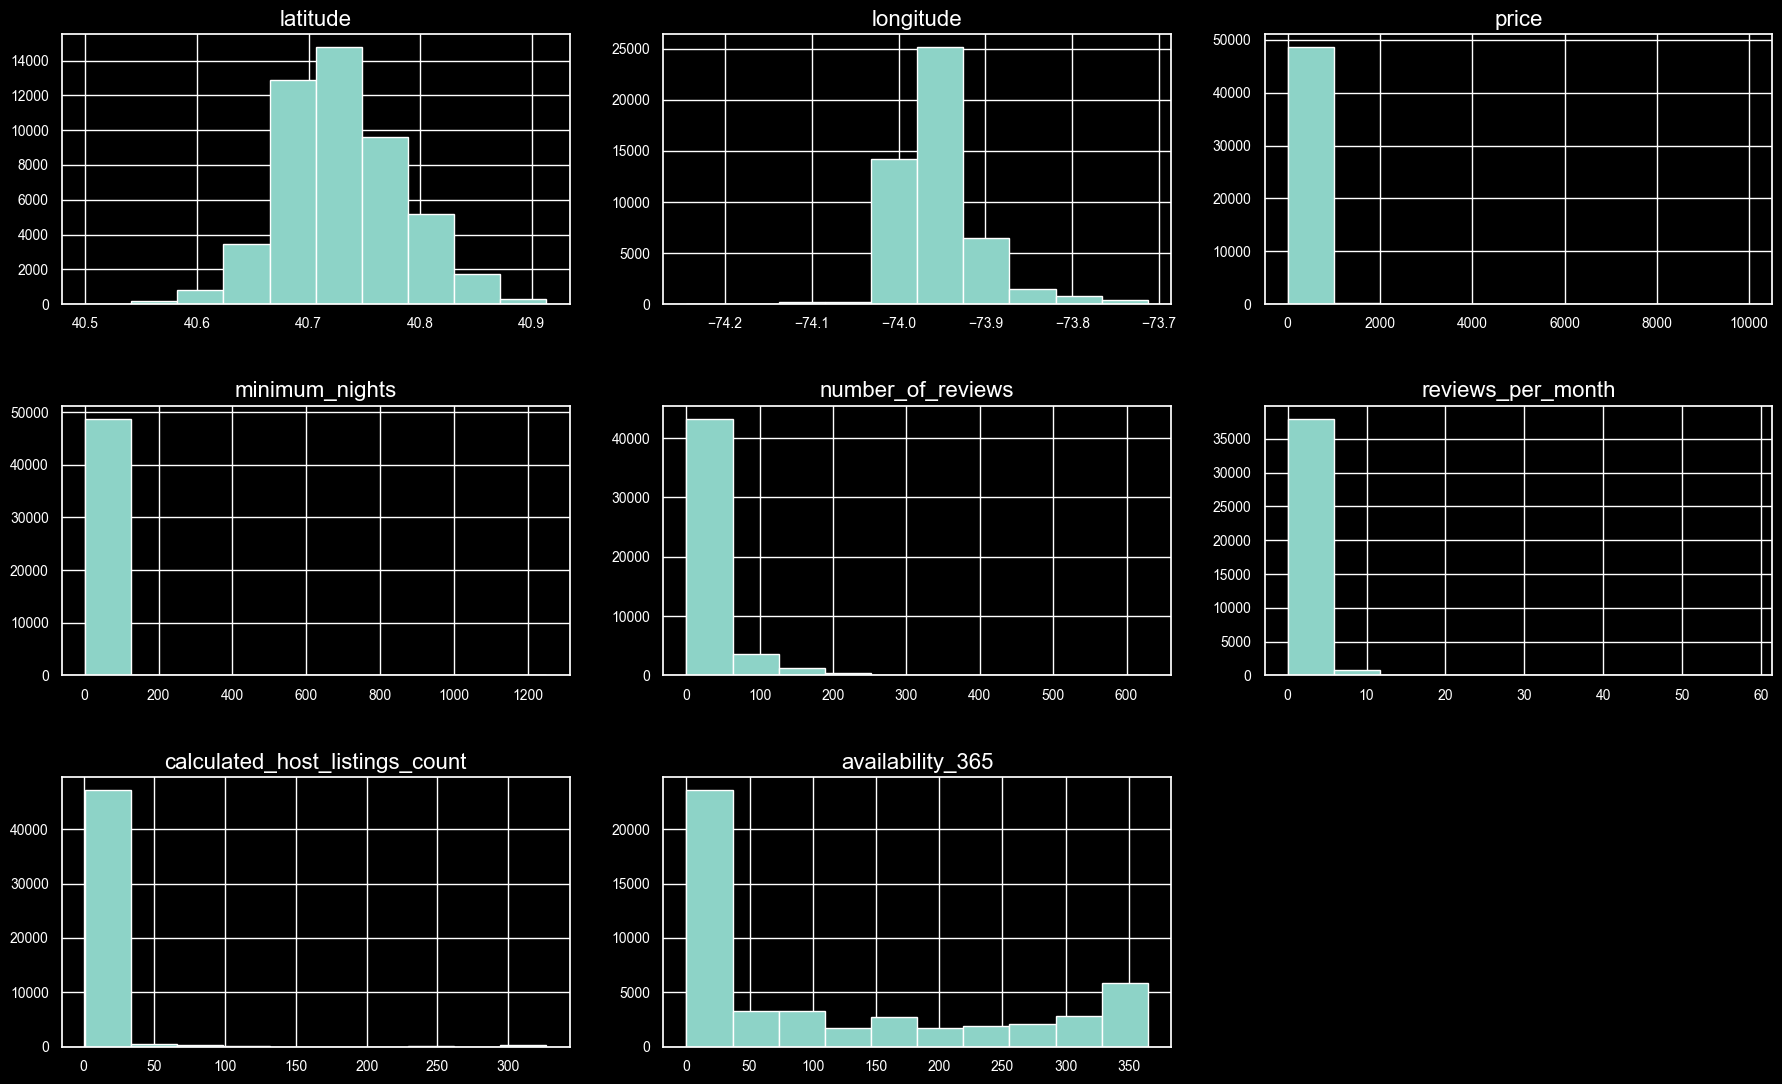

In [99]:
distribution_plot(df_raw)


In [20]:
for column in df_raw.columns:
    print(f'column: {column}')
    print(column_stats_table(df_raw, column))
    print('='*15)

#


column: neighbourhood_group
           value  count  percentage
0      Manhattan  21661   44.301053
1       Brooklyn  20104   41.116679
2         Queens   5666   11.588097
3          Bronx   1091    2.231312
4  Staten Island    373    0.762859
column: neighbourhood
                  value  count  percentage
0          Williamsburg   3920    8.017180
1    Bedford-Stuyvesant   3714    7.595869
2                Harlem   2658    5.436139
3              Bushwick   2465    5.041415
4       Upper West Side   1971    4.031087
..                  ...    ...         ...
216        Richmondtown      1    0.002045
217      Fort Wadsworth      1    0.002045
218            New Dorp      1    0.002045
219           Rossville      1    0.002045
220         Willowbrook      1    0.002045

[221 rows x 3 columns]
column: latitude
          value  count  percentage
0      40.71813     18    0.036814
1      40.68634     13    0.026588
2      40.68444     13    0.026588
3      40.69414     13    0.026588
4 

In [100]:
# duplicate check
duplicate_count = df_raw.duplicated().sum()
print(f"entire row duplicates: {duplicate_count}")

if duplicate_count > 0:
    duplicate_rows = df_raw[df_raw.duplicated()]
    print(duplicate_rows)
    print('-'*15)

entire row duplicates: 0


In [101]:
# check gaps in the columns
df_raw.isnull().sum()

null_amount = df_raw.isnull().sum()

if null_amount.sum() == 0:
    print('data gaps in cells - NO')
else:
    columns_with_null = null_amount[null_amount > 0].to_dict()
    print(columns_with_null)
print(f'total rows: {df_raw.shape[0]}')

{'reviews_per_month': 10052}
total rows: 48895


In [102]:
column_stats_table(df_raw,'reviews_per_month')


,value,count,percentage
0,0.02,919,2.365935
1,0.05,893,2.298999
2,1.00,893,2.298999
3,0.03,804,2.069871
4,0.16,667,1.717169
...,...,...,...
932,7.86,1,0.002574
933,11.71,1,0.002574
934,9.73,1,0.002574
935,10.91,1,0.002574


In [103]:
# проверил исходную таблицу (до удаления столбцов), если правильно понял бизнес логику, похоже что часть квартир/комнат не имела просмотров в месяце,
# решил все пробелы в этом столбце заменить нулями = 0 просмотров

df_raw['reviews_per_month'] = df_raw['reviews_per_month'].fillna(0)

# контрольная проверка распределения
column_stats_table(df_raw,'reviews_per_month')

,value,count,percentage
0,0.00,10052,20.558339
1,0.02,919,1.879538
2,0.05,893,1.826363
3,1.00,893,1.826363
4,0.03,804,1.644340
...,...,...,...
933,7.86,1,0.002045
934,11.71,1,0.002045
935,9.73,1,0.002045
936,10.91,1,0.002045


<Figure size 1600x1200 with 0 Axes>

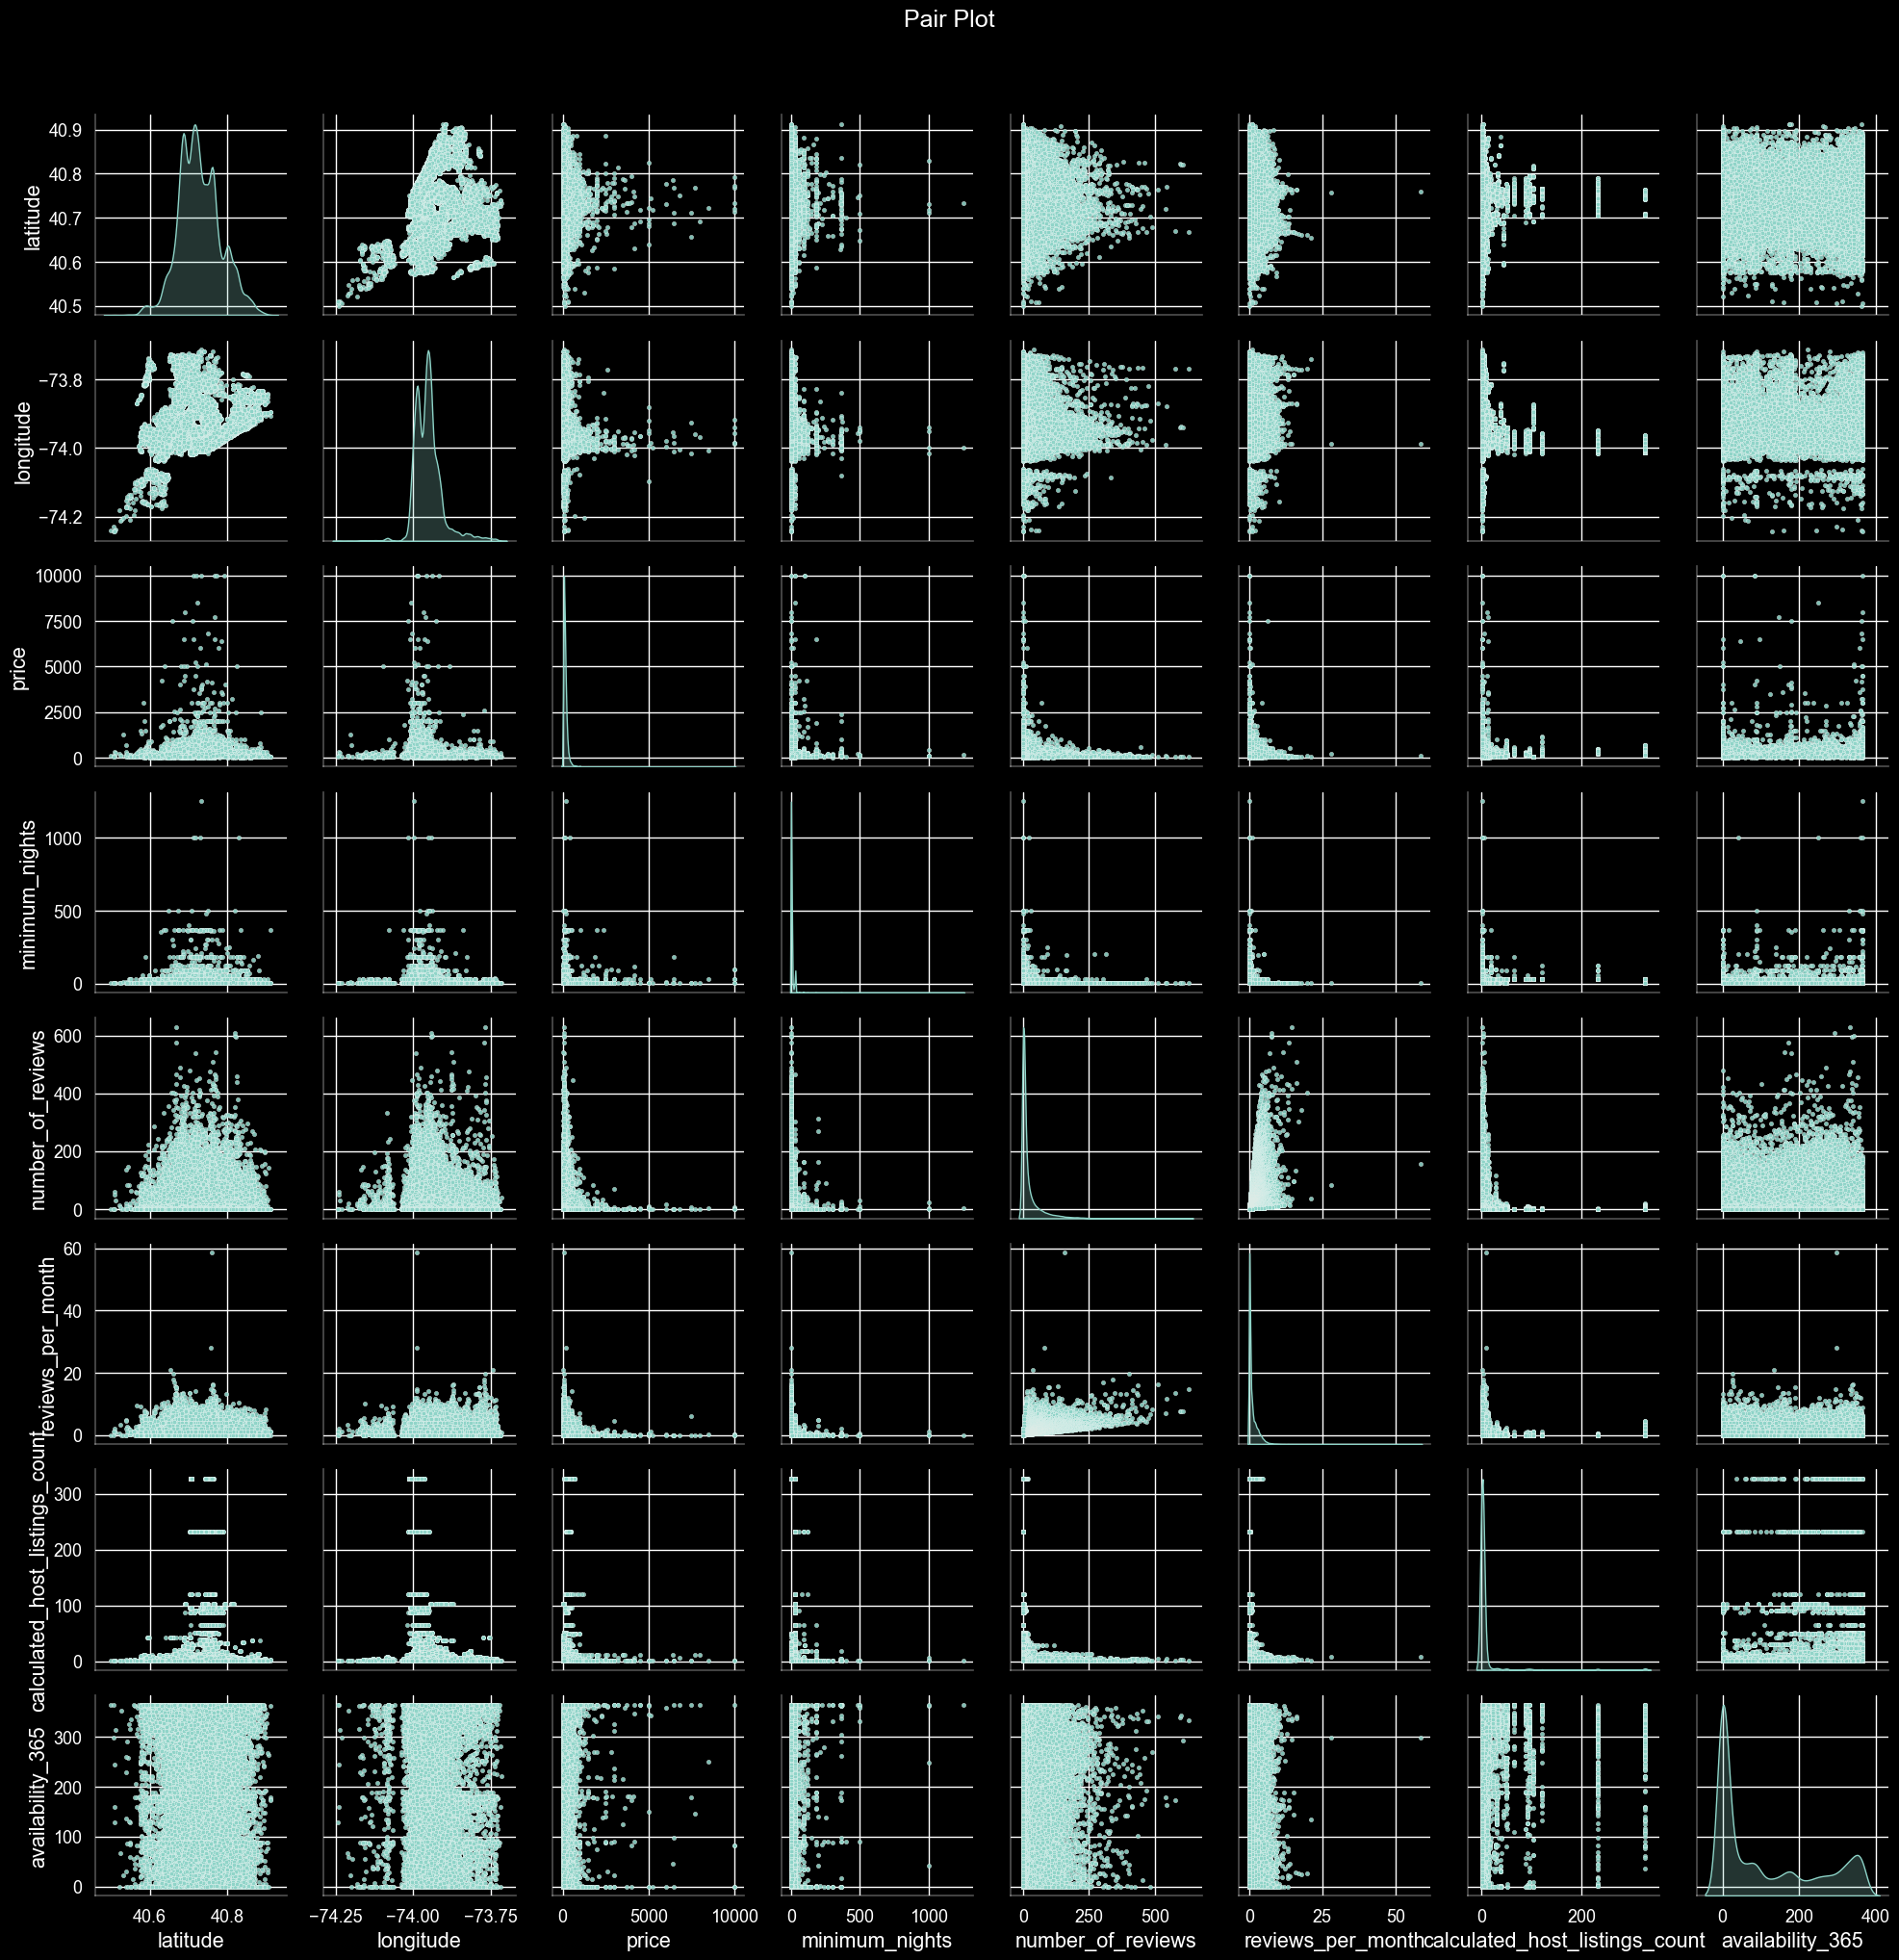

In [104]:
# pair plot
sns.set_context('notebook', font_scale=1.3)

plt.figure(figsize=(16, 12))
g = sns.pairplot(
    df_raw,
    diag_kind='kde',
    plot_kws={'alpha': 0.9, 's': 10},
    diag_kws={'fill': True}
)

for ax in g.axes.flatten():
    ax.tick_params(labelsize=13)
    for spine in ax.spines.values():
        spine.set_alpha(0.3)

plt.suptitle('Pair Plot', y=1.02, fontsize=18)
plt.tight_layout()
plt.show()

# Reset to default
sns.set_context('notebook')


In [139]:
# Column encodings and feature engineering

# neighbourhood_group -> ohe: prefix area_
# room_type -> ohe: prefix rtype_



# neighbourhood_group
def column_to_ohe(df_name, column_name, prefix_name): # e.g.: 'area_'
    encoded_cols = []
    encoded_cols = df_name.columns[df_name.columns.str.startswith(prefix_name)]
    if encoded_cols.size > 0:
        df_name.drop(columns=encoded_cols, inplace=True)

    # join ohe columns, drop the original column after that
    idx = df_name.columns.get_loc(column_name)
    column_ohe = pd.get_dummies(df_name[column_name], prefix=prefix_name, dtype=int)

    for i, col_name in enumerate(column_ohe.columns):
        df_name.insert(idx +1 +i, col_name, column_ohe[col_name])

    df_name = df_name.drop(column_name, axis=1)
    return df_name


# neighbourhood -> manhattan center distance

def calculate_distance_to_manhattan(df_name, column_name='manh_center_dist', lat_col='latitude', lon_col='longitude'):


    if column_name in df_name.columns:
        df_name.drop(columns=column_name, inplace=True)

    # Manhattan center
    center_lat = 40.7831
    center_lon = -73.9712

    # Differences
    delta_lat = df_name[lat_col].values - center_lat
    delta_lon = df_name[lon_col].values - center_lon

    # Convert to meters
    lat_m = delta_lat * 111320

    # geo vectors |_
    avg_lat = np.radians((df_name[lat_col].values + center_lat) / 2)
    lon_m = delta_lon * 111320 * np.cos(avg_lat)

    # Euclidean distance
    distance = np.sqrt(lat_m**2 + lon_m**2)
    idx = df_name.columns.get_loc('neighbourhood')
    # df_name.insert(idx +1, column_name)
    df_name.insert(idx + 1, column_name, distance)

    return df_name


def label_encode(df_name, column_name, suffix_name='_coded'):
    # check if the column has already been encoded, drop it if so
    if suffix_name in df_name.columns:
        df_name.drop(columns=[suffix_name], inplace=True)

    # find index of the original column
    idx = df_name.columns.get_loc(column_name)

    # standard label encoding using pandas categorical codes
    column_encoded = df_name[column_name].astype('category').cat.codes

    # insert the new encoded column right after the original column
    df_name.insert(idx + 1, column_name + suffix_name, column_encoded)

    # drop the original text column
    df_name = df_name.drop(column_name, axis=1)
    return df_name


def price_mult_nights(df_name, prefix_name='calc'):

    mult = df_name['price'] * df_name['minimum_nights']

    new_col = f'{prefix_name}_price_x_nights'

    # Insert after price column
    idx = df_name.columns.get_loc('price')
    df_name.insert(idx + 1, new_col, mult)

    return df_name



In [141]:
# DF to model

df_encoded = df_raw.copy()

In [132]:
# apply ohe
df_encoded = column_to_ohe(df_encoded, 'neighbourhood_group', 'area')
df_encoded = column_to_ohe(df_encoded, 'room_type', 'rtype')

In [133]:
# apply distance to manhattan
df_encoded = calculate_distance_to_manhattan(df_encoded)
df_encoded = df_encoded.drop('neighbourhood', axis=1)

# df_encoded = price_mult_nights(df_encoded) # читинг, но даже с этой фичей MAE=$26.25, RMSE=$180.39

In [142]:
columns_to_encode = ['neighbourhood', 'neighbourhood_group', 'room_type']

for col in columns_to_encode:
    df = label_encode(df_encoded, col)

for col in columns_to_encode:
    df_encoded = df_encoded.drop(col, axis=1)


,neighbourhood_group_coded,neighbourhood_coded,latitude,longitude,room_type_coded,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,1,108,40.64749,-73.97237,1,149,1,9,0.21,6,365
1,2,127,40.75362,-73.98377,0,225,1,45,0.38,2,355
2,2,94,40.80902,-73.94190,1,150,3,0,0.00,1,365
3,1,41,40.68514,-73.95976,0,89,1,270,4.64,1,194
4,2,61,40.79851,-73.94399,0,80,10,9,0.10,1,0


In [136]:
df_encoded.head()

,area_Bronx,area_Brooklyn,area_Manhattan,area_Queens,area_Staten Island,manh_center_dist,latitude,longitude,rtype_Entire home/apt,rtype_Private room,rtype_Shared room,price,calc_price_x_nights,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,0,1,0,0,0,15096.427984,40.64749,-73.97237,0,1,0,149,149,1,9,0.21,6,365
1,0,0,1,0,0,3448.585221,40.75362,-73.98377,1,0,0,225,225,1,45,0.38,2,355
2,0,0,1,0,0,3797.717670,40.80902,-73.94190,0,1,0,150,450,3,0,0.00,1,365
3,0,1,0,0,0,10947.520573,40.68514,-73.95976,1,0,0,89,89,1,270,4.64,1,194
4,0,0,1,0,0,2863.881910,40.79851,-73.94399,1,0,0,80,800,10,9,0.10,1,0


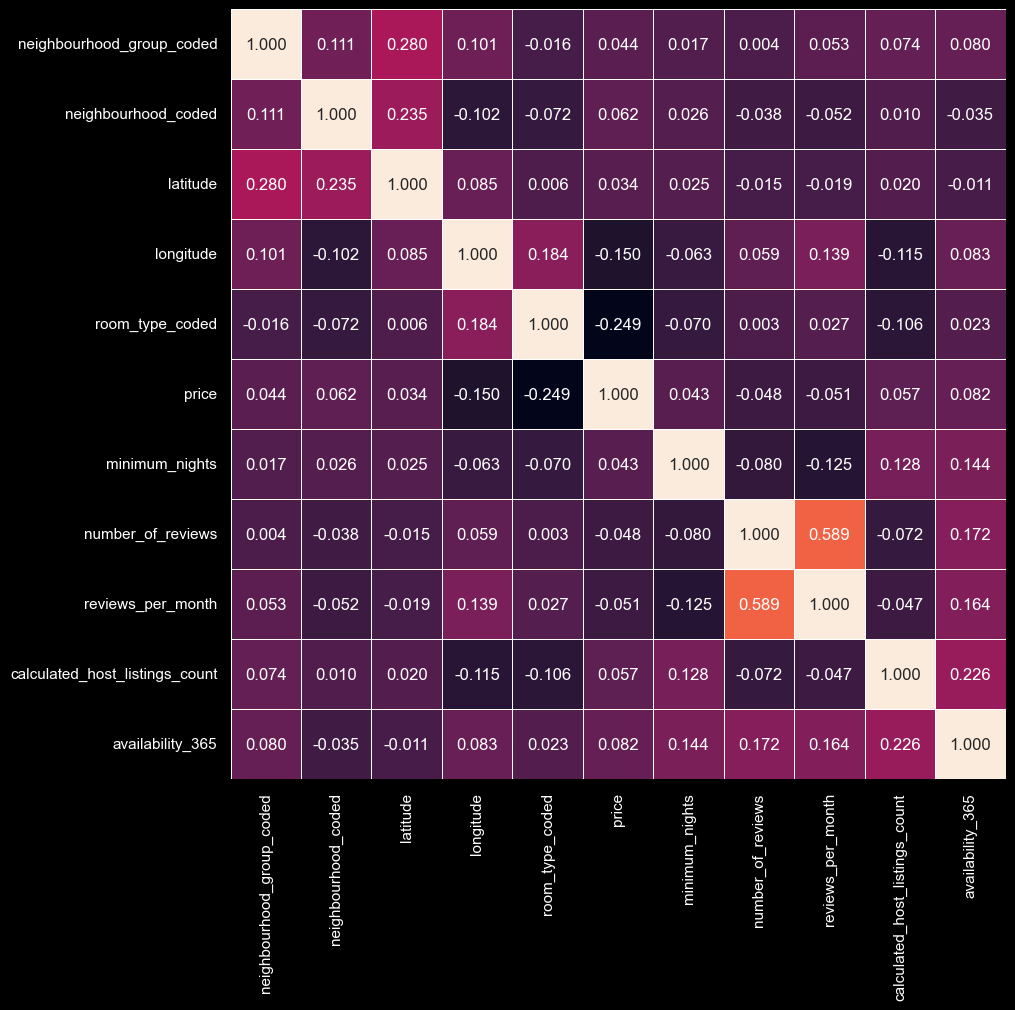

In [143]:
# correlation heatmap

plt.figure(figsize=(10, 10))
sns.heatmap(df_encoded.corr(), annot=True, cbar=False, linewidths=.5, fmt='.3f')
plt.show()


In [149]:
# pipeline upd


import pandas as pd
import numpy as np
import time
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

import matplotlib.pyplot as plt

# ============================================
# CONFIG
# ============================================

class ModelConfig:

    def __init__(self):
        # Dataset split
        self.test_size = 0.20
        self.val_size = 0.20
        self.random_state = 555
        self.shuffle = True

        # Model flags
        self.run_linear_regression = True
        self.run_ridge = True
        self.run_lasso = True
        self.run_elasticnet = True
        self.run_random_forest = True

        # Target transformation
        self.use_log_transform = True

        # Grid search vars
        self.ridge_alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0, 1000.0]
        self.lasso_alphas = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]
        self.lasso_max_iter = [10000, 50000]
        self.enet_alphas = [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0]
        self.enet_l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]
        self.enet_max_iter = [10000, 50000]

        # added for rforest
        self.rf_n_estimators = [50, 100, 200, 300]
        self.rf_max_depth = [None, 10, 20, 30, 50]
        self.rf_min_samples_split = [2, 5, 10]
        self.rf_min_samples_leaf = [1, 2, 4]
        self.rf_max_features = ['sqrt', 'log2', None]

        # Cross validation folds
        self.cv_folds = 5

        # Log results
        self.detailed_log = True

        # log file
        self.results_file = 'model_results.csv'
        self.append_results = True  # append/replace logs

# ============================================
# HELPER FUNCTIONS
# ============================================

def log_transform_target(Y, use_log_transform=True):
    #log transform for imbalanced target
    if use_log_transform and Y.skew() > 1:
        print(f'Price skewness: {Y.skew():.4f} - do log transform...')
        Y_transformed = np.log1p(Y)
        print(f'Log price skewness: {Y_transformed.skew():.4f}')
        return Y_transformed, True
    return Y, False

def calculate_metrics(y_true, y_pred, use_log_transform=False):

    if use_log_transform:
        y_true_orig = np.expm1(y_true)
        y_pred_orig = np.expm1(y_pred)
    else:
        y_true_orig = y_true
        y_pred_orig = y_pred

    return {
        'R2': r2_score(y_true, y_pred),
        'MAE': mean_absolute_error(y_true_orig, y_pred_orig),
        'RMSE': np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    }

def print_results(name, train_metrics, val_metrics, test_metrics, params=None, detailed=True):
    if not detailed:
        return

    print(f"\n{'='*15}")
    print(f'MODEL: {name}')
    print('-'*15)

    if params:
        print(f'Best params: {params}')

    print(f'train: R2={train_metrics["R2"]:.4f}, MAE=${train_metrics["MAE"]:.2f}, RMSE=${train_metrics["RMSE"]:.2f}')
    print(f'validation: R2={val_metrics["R2"]:.4f}, MAE=${val_metrics["MAE"]:.2f}, RMSE=${val_metrics["RMSE"]:.2f}')
    print(f'test: R2={test_metrics["R2"]:.4f}, MAE=${test_metrics["MAE"]:.2f}, RMSE=${test_metrics["RMSE"]:.2f}')

    overfit_gap = train_metrics['R2'] - val_metrics['R2']
    if overfit_gap > 0.1:
        print(f'Model might be overtrained! Train R2 - Val R2 = {overfit_gap:.4f}')

def save_results_to_csv(results_df, filename, append=True):
    # csv log file
    if append and os.path.exists(filename):
        existing_df = pd.read_csv(filename)
        combined_df = pd.concat([existing_df, results_df], ignore_index=True)
        combined_df.to_csv(filename, index=False)
        print(f'Result saved: {filename} (Total: {len(combined_df)} rows)')
    else:
        # Create new file or overwrite
        results_df.to_csv(filename, index=False)
        print(f'Result saved: {filename} (New file, {len(results_df)} rows)')

# ============================================
# MODEL TRAIN
# ============================================

def train_linear_regression(X_train, X_val, X_test, y_train, y_val, y_test, use_log_transform=False, detailed=True):

    if detailed:
        print('\n' + '='*15)
        print('MODEL 1: LINEAR REGRESSION')
        print('-'*15)

    start_time = time.time()
    model = LinearRegression()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    # Split dataset
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    # Metrics
    train_metrics = calculate_metrics(y_train, y_train_pred, use_log_transform)
    val_metrics = calculate_metrics(y_val, y_val_pred, use_log_transform)
    test_metrics = calculate_metrics(y_test, y_test_pred, use_log_transform)

    if detailed:
        print_results('Linear Regression', train_metrics, val_metrics, test_metrics)

    return {
        'model': model,
        'train_metrics': train_metrics,
        'val_metrics': val_metrics,
        'test_metrics': test_metrics,
        'params': None,
        'train_time': train_time
    }

def train_ridge_cv(X_train, X_val, X_test, y_train, y_val, y_test, alphas=None, cv_folds=5,
                   use_log_transform=False, detailed=True):
    if detailed:
        print('\n' + '='*15)
        print('MODEL 2: RIDGE CV')
        print('-'*15)
        print('Grid search for RidgeCV')

    if alphas is None:
        alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0, 1000.0]

    start_time = time.time()
    best_r2 = -np.inf
    best_params = None
    best_model = None

    for alpha in alphas:
        ridge = RidgeCV(alphas=[alpha], cv=cv_folds)
        ridge.fit(X_train, y_train)

        y_val_pred = ridge.predict(X_val)
        val_r2 = r2_score(y_val, y_val_pred)

        if detailed:
            print(f'alpha={alpha}: Validation R2={val_r2:.4f}')

        if val_r2 > best_r2:
            best_r2 = val_r2
            best_params = {"alpha": alpha}
            best_model = ridge

    train_time = time.time() - start_time

    if detailed:
        print(f'\nBest parameters: alpha={best_params["alpha"]}')
        print(f'Best validation R2={best_r2:.4f}')

    # Predictions with best model
    y_train_pred = best_model.predict(X_train)
    y_val_pred = best_model.predict(X_val)
    y_test_pred = best_model.predict(X_test)

    # Metrics
    train_metrics = calculate_metrics(y_train, y_train_pred, use_log_transform)
    val_metrics = calculate_metrics(y_val, y_val_pred, use_log_transform)
    test_metrics = calculate_metrics(y_test, y_test_pred, use_log_transform)

    if detailed:
        print_results('RidgeCV', train_metrics, val_metrics, test_metrics, best_params)

    return {
        'model': best_model,
        'train_metrics': train_metrics,
        'val_metrics': val_metrics,
        'test_metrics': test_metrics,
        'params': best_params,
        'train_time': train_time
    }

def train_lasso_cv(X_train, X_val, X_test, y_train, y_val, y_test, alphas=None, max_iter_options=None,
                   cv_folds=5, use_log_transform=False, detailed=True):
    """Train LassoCV model with grid search."""
    if detailed:
        print('\n' + '='*15)
        print('MODEL 3: LASSO CV')
        print('-'*15)
        print("Grid search for LassoCV model..")

    if alphas is None:
        alphas = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]
    if max_iter_options is None:
        max_iter_options = [10000, 50000]

    start_time = time.time()
    best_r2 = -np.inf
    best_params = None
    best_model = None

    for alpha in alphas:
        for max_iter in max_iter_options:
            lasso = LassoCV(
                alphas=[alpha],
                max_iter=max_iter,
                cv=cv_folds,
                random_state=555
            )

            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                lasso.fit(X_train, y_train)

            y_val_pred = lasso.predict(X_val)
            val_r2 = r2_score(y_val, y_val_pred)

            if detailed:
                print(f'alpha={alpha}, max_iter={max_iter}: Validation R2={val_r2:.4f}')

            if val_r2 > best_r2:
                best_r2 = val_r2
                best_params = {"alpha": alpha, "max_iter": max_iter}
                best_model = lasso

    train_time = time.time() - start_time

    if detailed:
        print(f'\nBest parameters: alpha={best_params["alpha"]}, max_iter={best_params["max_iter"]}')
        print(f'Best validation R2={best_r2:.4f}')

    # Predictions with best model
    y_train_pred = best_model.predict(X_train)
    y_val_pred = best_model.predict(X_val)
    y_test_pred = best_model.predict(X_test)

    # Metrics
    train_metrics = calculate_metrics(y_train, y_train_pred, use_log_transform)
    val_metrics = calculate_metrics(y_val, y_val_pred, use_log_transform)
    test_metrics = calculate_metrics(y_test, y_test_pred, use_log_transform)

    # Feature selection info
    zero_coefs = np.sum(np.abs(best_model.coef_) < 1e-6)
    if detailed:
        print(f"\nFeature selection: {zero_coefs}/{len(best_model.coef_)} features removed")
        print_results('LassoCV', train_metrics, val_metrics, test_metrics, best_params)

    return {
        'model': best_model,
        'train_metrics': train_metrics,
        'val_metrics': val_metrics,
        'test_metrics': test_metrics,
        'params': best_params,
        'train_time': train_time,
        'zero_coefs': zero_coefs
    }

def train_elasticnet_cv(X_train, X_val, X_test, y_train, y_val, y_test, alphas=None, l1_ratios=None,
                        max_iter_options=None, cv_folds=5, use_log_transform=False, detailed=True):
    """Train ElasticNetCV model with grid search."""
    if detailed:
        print('\n' + '='*15)
        print('MODEL 4: ELASTIC NET CV')
        print('-'*15)
        print("Grid search for ElasticNetCV model..")

    if alphas is None:
        alphas = [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0]
    if l1_ratios is None:
        l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]
    if max_iter_options is None:
        max_iter_options = [10000, 50000]

    start_time = time.time()
    best_r2 = -np.inf
    best_params = None
    best_model = None

    for alpha in alphas:
        for l1_ratio in l1_ratios:
            for max_iter in max_iter_options:
                enet = ElasticNetCV(
                    alphas=[alpha],
                    l1_ratio=[l1_ratio],
                    max_iter=max_iter,
                    cv=cv_folds,
                    random_state=555
                )

                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    enet.fit(X_train, y_train)

                y_val_pred = enet.predict(X_val)
                val_r2 = r2_score(y_val, y_val_pred)

                if detailed:
                    print(f'alpha={alpha}, l1_ratio={l1_ratio}, max_iter={max_iter}: Validation R2={val_r2:.4f}')

                if val_r2 > best_r2:
                    best_r2 = val_r2
                    best_params = {
                        "alpha": alpha,
                        "l1_ratio": l1_ratio,
                        "max_iter": max_iter
                    }
                    best_model = enet

    train_time = time.time() - start_time

    if detailed:
        print(f'\nBest parameters: alpha={best_params["alpha"]}, l1_ratio={best_params["l1_ratio"]}, max_iter={best_params["max_iter"]}')
        print(f'Best validation R2={best_r2:.4f}')

    # Predictions with best model
    y_train_pred = best_model.predict(X_train)
    y_val_pred = best_model.predict(X_val)
    y_test_pred = best_model.predict(X_test)

    # Metrics
    train_metrics = calculate_metrics(y_train, y_train_pred, use_log_transform)
    val_metrics = calculate_metrics(y_val, y_val_pred, use_log_transform)
    test_metrics = calculate_metrics(y_test, y_test_pred, use_log_transform)

    if detailed:
        print_results('ElasticNetCV', train_metrics, val_metrics, test_metrics, best_params)

    return {
        'model': best_model,
        'train_metrics': train_metrics,
        'val_metrics': val_metrics,
        'test_metrics': test_metrics,
        'params': best_params,
        'train_time': train_time
    }

def train_random_forest(X_train, X_val, X_test, y_train, y_val, y_test,
                        n_estimators=None, max_depth=None, min_samples_split=None,
                        min_samples_leaf=None, max_features=None,
                        use_log_transform=False, detailed=True):
    """
    Train Random Forest Regressor with grid search.
    """
    if detailed:
        print('\n' + '='*15)
        print('MODEL 5: RANDOM FOREST')
        print('-'*15)
        print('Grid search for Random Forest')

    # Default parameters
    if n_estimators is None:
        n_estimators = [50, 100, 200, 300]
    if max_depth is None:
        max_depth = [None, 10, 20, 30, 50]
    if min_samples_split is None:
        min_samples_split = [2, 5, 10]
    if min_samples_leaf is None:
        min_samples_leaf = [1, 2, 4]
    if max_features is None:
        max_features = ['sqrt', 'log2', None]

    start_time = time.time()
    best_r2 = -np.inf
    best_params = None
    best_model = None

    # Simplified grid search (to avoid too many combinations)
    param_grid = {
        'n_estimators': n_estimators[:3],
        'max_depth': max_depth[:3],
        'min_samples_split': min_samples_split[:2],
        'min_samples_leaf': min_samples_leaf[:2],
        'max_features': max_features[:2]
    }

    # check total combinations
    total_combinations = 1
    for v in param_grid.values():
        total_combinations *= len(v)

    if detailed:
        print(f'Total parameter combinations: {total_combinations}')

    # Manual grid search
    for n_est in param_grid['n_estimators']:
        for depth in param_grid['max_depth']:
            for min_split in param_grid['min_samples_split']:
                for min_leaf in param_grid['min_samples_leaf']:
                    for max_feat in param_grid['max_features']:

                        rf = RandomForestRegressor(
                            n_estimators=n_est,
                            max_depth=depth,
                            min_samples_split=min_split,
                            min_samples_leaf=min_leaf,
                            max_features=max_feat,
                            random_state=555,
                            n_jobs=-1,
                            verbose=0
                        )

                        rf.fit(X_train, y_train)
                        y_val_pred = rf.predict(X_val)
                        val_r2 = r2_score(y_val, y_val_pred)

                        if detailed:
                            print(f'n={n_est}, depth={depth}, min_split={min_split}, '
                                  f'min_leaf={min_leaf}, max_feat={max_feat}: '
                                  f'Validation R2={val_r2:.4f}')

                        if val_r2 > best_r2:
                            best_r2 = val_r2
                            best_params = {
                                'n_estimators': n_est,
                                'max_depth': depth,
                                'min_samples_split': min_split,
                                'min_samples_leaf': min_leaf,
                                'max_features': max_feat
                            }
                            best_model = rf

    train_time = time.time() - start_time

    if detailed:
        print(f'\nBest parameters: {best_params}')
        print(f'Best validation R2={best_r2:.4f}')

    # Predictions with best model
    y_train_pred = best_model.predict(X_train)
    y_val_pred = best_model.predict(X_val)
    y_test_pred = best_model.predict(X_test)

    # Metrics
    train_metrics = calculate_metrics(y_train, y_train_pred, use_log_transform)
    val_metrics = calculate_metrics(y_val, y_val_pred, use_log_transform)
    test_metrics = calculate_metrics(y_test, y_test_pred, use_log_transform)

    # Feature importance
    feature_importance = None
    if hasattr(best_model, 'feature_importances_'):
        feature_importance = best_model.feature_importances_
        if detailed:
            print(f'\nTop 10 most important features:')
            if hasattr(X_train, 'columns'):
                importance_df = pd.DataFrame({
                    'feature': X_train.columns,
                    'importance': feature_importance
                }).sort_values('importance', ascending=False)
                print(importance_df.head(10).to_string(index=False))

    if detailed:
        print_results('Random Forest', train_metrics, val_metrics, test_metrics, best_params)

    return {
        'model': best_model,
        'train_metrics': train_metrics,
        'val_metrics': val_metrics,
        'test_metrics': test_metrics,
        'params': best_params,
        'train_time': train_time,
        'feature_importance': feature_importance
    }

# ============================================
# MAIN MODELS PIPELINE
# ============================================

def run_model_pipeline(df, config=None):

    if config is None:
        config = ModelConfig()

    print('\n' + "="*60)
    print('LINEAR MODELS PIPELINE')
    print('='*60)

    # 1. PREPARE DATA
    print('\n' + "="*60)
    print('DATA PREPARATION')
    print('='*60)

    target = 'price'
    Y = df[target]
    X_raw = df.drop([target], axis=1)

    print(f'Dataset shape: {X_raw.shape}')
    print(f'Features: {X_raw.shape[1]}')
    print(f'Samples: {X_raw.shape[0]}')
    print(f'Price range: ${Y.min():.2f} - ${Y.max():.2f}')
    print(f'Price mean: ${Y.mean():.2f}')
    print(f'Price skewness: {Y.skew():.4f}')

    # 2. LOG TRANSFORM TARGET
    Y, use_log_transform = log_transform_target(Y, config.use_log_transform)
    config.use_log_transform = use_log_transform

    # 3. SPLIT DATA
    print('\n' + "="*60)
    print('DATA SPLITTING')
    print('='*60)

    # Calculate split size
    test_size = config.test_size
    val_size = config.val_size / (1 - test_size)

    # First split: test set
    X_temp, X_test, y_temp, y_test = train_test_split(
        X_raw, Y,
        test_size=test_size,
        random_state=config.random_state,
        shuffle=config.shuffle
    )

    # Second split: validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp,
        test_size=val_size,
        random_state=config.random_state,
        shuffle=config.shuffle
    )

    print(f'Training:   {len(X_train):,} samples ({len(X_train)/len(X_raw)*100:.1f}%)')
    print(f'Validation: {len(X_val):,} samples ({len(X_val)/len(X_raw)*100:.1f}%)')
    print(f'Test:       {len(X_test):,} samples ({len(X_test)/len(X_raw)*100:.1f}%)')

    # 4. SCALE FEATURES
    print('\n' + "="*60)
    print('FEATURE SCALING')
    print('='*60)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    print('Features scaled (mean=0, std=1)')

    X_train_raw = X_train.values if hasattr(X_train, 'values') else X_train
    X_val_raw = X_val.values if hasattr(X_val, 'values') else X_val
    X_test_raw = X_test.values if hasattr(X_test, 'values') else X_test

    # 5. TRAIN MODELS
    print("\n" + "="*60)
    print('MODEL TRAINING')
    print('='*60)

    results = {}
    all_results = []  # for CSV

    # Apply config
    model_configs = [
        ('Linear Regression', config.run_linear_regression, train_linear_regression, {}, 'scaled'),
        ('RidgeCV', config.run_ridge, train_ridge_cv, {
            'alphas': config.ridge_alphas,
            'cv_folds': config.cv_folds
        }, 'scaled'),
        ('LassoCV', config.run_lasso, train_lasso_cv, {
            'alphas': config.lasso_alphas,
            'max_iter_options': config.lasso_max_iter,
            'cv_folds': config.cv_folds
        }, 'scaled'),
        ('ElasticNetCV', config.run_elasticnet, train_elasticnet_cv, {
            'alphas': config.enet_alphas,
            'l1_ratios': config.enet_l1_ratios,
            'max_iter_options': config.enet_max_iter,
            'cv_folds': config.cv_folds
        }, 'scaled'),
        ('Random Forest', config.run_random_forest, train_random_forest, {
            'n_estimators': config.rf_n_estimators,
            'max_depth': config.rf_max_depth,
            'min_samples_split': config.rf_min_samples_split,
            'min_samples_leaf': config.rf_min_samples_leaf,
            'max_features': config.rf_max_features
        }, 'raw')
    ]

    # get timestamp
    run_timestamp = pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')

    for name, run_flag, train_func, kwargs, data_type in model_configs:
        if run_flag:
            if data_type == 'scaled':
                X_tr, X_vl, X_te = X_train_scaled, X_val_scaled, X_test_scaled
            else:  # raw data without scaling
                X_tr, X_vl, X_te = X_train_raw, X_val_raw, X_test_raw

            result = train_func(
                X_tr, X_vl, X_te,
                y_train, y_val, y_test,
                use_log_transform=use_log_transform,
                detailed=config.detailed_log,
                **kwargs
            )
            results[name] = result

            # object to csv
            row = {
                'timestamp': run_timestamp,
                'model_name': name,
                'train_time_sec': result['train_time'],
                'train_r2': result['train_metrics']['R2'],
                'val_r2': result['val_metrics']['R2'],
                'test_r2': result['test_metrics']['R2'],
                'train_mae': result['train_metrics']['MAE'],
                'val_mae': result['val_metrics']['MAE'],
                'test_mae': result['test_metrics']['MAE'],
                'train_rmse': result['train_metrics']['RMSE'],
                'val_rmse': result['val_metrics']['RMSE'],
                'test_rmse': result['test_metrics']['RMSE'],
                'n_features': X_raw.shape[1],
                'n_samples': X_raw.shape[0],
                'test_size': config.test_size,
                'val_size': config.val_size,
                'random_state': config.random_state,
                'use_log_transform': use_log_transform
            }

            # Add parameters if exist
            if result['params']:
                for param_name, param_value in result['params'].items():
                    # name for csv file
                    clean_param_name = param_name.replace(' ', '_').replace('(', '').replace(')', '')
                    row[f'param_{clean_param_name}'] = param_value

            # Added random forest details
            if name == 'Random Forest' and 'feature_importance' in result:
                if result['feature_importance'] is not None:
                    # get top 5 feature importances
                    if hasattr(X_train, 'columns'):
                        importance_df = pd.DataFrame({
                            'feature': X_train.columns,
                            'importance': result['feature_importance']
                        }).sort_values('importance', ascending=False)

                        for i in range(min(5, len(importance_df))):
                            row[f'top_{i+1}_feature'] = importance_df.iloc[i]['feature']
                            row[f'top_{i+1}_importance'] = importance_df.iloc[i]['importance']

            all_results.append(row)

    # 6. MODEL COMPARISON
    print('\n' + "="*60)
    print('MODEL COMPARISON (TEST SET PERFORMANCE)')
    print('='*60)

    if all_results:
        comparison_df = pd.DataFrame(all_results)

        # Display comparison
        display_cols = ['model_name', 'test_r2', 'test_mae', 'test_rmse', 'train_time_sec']
        print(comparison_df[display_cols].to_string(index=False))

        # Find best model
        best_idx = comparison_df['test_r2'].idxmax()
        best_model_name = comparison_df.loc[best_idx, 'model_name']

        print(f'\n{"="*60}')
        print(f'BEST MODEL ON TEST SET: {best_model_name}')
        print('='*60)
        print(f'Test R2:  {comparison_df.loc[best_idx, "test_r2"]:.4f}')
        print(f'Test MAE:  ${comparison_df.loc[best_idx, "test_mae"]:.2f}')
        print(f'Test RMSE: ${comparison_df.loc[best_idx, "test_rmse"]:.2f}')
        print(f'Training time: {comparison_df.loc[best_idx, "train_time_sec"]:.2f} seconds')

        # Save results to CSV with append logic
        if config.results_file:
            save_results_to_csv(comparison_df, config.results_file, append=config.append_results)

        return results, comparison_df
    else:
        print('Check your config, no models to train')
        return results, None


In [152]:
# run pipeline

config = ModelConfig()

# dataset split
config.test_size = 0.30
config.val_size = 0.20
config.random_state = 555

# model toggles
config.run_linear_regression = False
config.run_ridge = False
config.run_lasso = False
config.run_elasticnet = False
config.run_random_forest = True

# Grid search config
config.ridge_alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
config.lasso_alphas = [0.001, 0.01, 0.1, 1.0, 10.0]
config.lasso_max_iter = [15000, 30000]
config.enet_alphas = [0.001, 0.01, 0.1, 1.0]
config.enet_l1_ratios = [0.1, 0.5, 0.9]
config.enet_max_iter = [15000, 30000]

# Added random forest config
config.rf_n_estimators = [150, 200, 250]  # [50, 100, 200, 300]
config.rf_max_depth = [15, 20, 25]  # [10, 20, 30]
config.rf_min_samples_split = [2, 3, 5]
config.rf_min_samples_leaf = [1, 2, 3]
config.rf_max_features = ['sqrt', 'log2']

# Log result
config.detailed_log = True
config.results_file = 'model_results.csv'
config.append_results = True  # Append into file


# Run pipeline
results, comparison_df = run_model_pipeline(df_encoded, config)

#
#



LINEAR MODELS PIPELINE

DATA PREPARATION
Dataset shape: (48895, 10)
Features: 10
Samples: 48895
Price range: $0.00 - $10000.00
Price mean: $152.72
Price skewness: 19.1189
Price skewness: 19.1189 - do log transform...
Log price skewness: 0.5531

DATA SPLITTING
Training:   24,447 samples (50.0%)
Validation: 9,779 samples (20.0%)
Test:       14,669 samples (30.0%)

FEATURE SCALING
Features scaled (mean=0, std=1)

MODEL TRAINING

MODEL 5: RANDOM FOREST
---------------
Grid search for Random Forest
Total parameter combinations: 72
n=150, depth=15, min_split=2, min_leaf=1, max_feat=sqrt: Validation R2=0.6081
n=150, depth=15, min_split=2, min_leaf=1, max_feat=log2: Validation R2=0.6081
n=150, depth=15, min_split=2, min_leaf=2, max_feat=sqrt: Validation R2=0.6079
n=150, depth=15, min_split=2, min_leaf=2, max_feat=log2: Validation R2=0.6079
n=150, depth=15, min_split=3, min_leaf=1, max_feat=sqrt: Validation R2=0.6077
n=150, depth=15, min_split=3, min_leaf=1, max_feat=log2: Validation R2=0.6077

первый прогон дал вот такие результаты


            Model    CV R²    CV MAE    CV RMSE  Train R²  Train MAE  Train RMSE
Linear Regression 0.097096 73.722562 226.601559  0.100061  73.428225  227.820163
          RidgeCV 0.097126 73.566964 226.599320  0.100039  73.307396  227.822945
          LassoCV 0.097143 73.368218 226.598817  0.099909  73.097193  227.839500
     ElasticNetCV 0.097145 73.585612 226.596744  0.100040  73.300763  227.822836

Best parameters: alpha=0.1, l1_ratio=0.95, max_iter=10000
Best R²=0.0971